In [1]:
import torch
import tiktoken
enc=tiktoken.get_encoding('gpt2')

In [2]:
from train_gpt2 import GPT2Config,GPT2
checkpoint=torch.load("gpt2_step_11500.pt",map_location="cpu")
for key in list(checkpoint.keys()):
    if key.startswith('_orig_mod.'):
        checkpoint[key[len('_orig_mod.'):]]=checkpoint.pop(key)

model=GPT2(GPT2Config())
model.load_state_dict(checkpoint,strict=False)


_IncompatibleKeys(missing_keys=['transformer.h.0.attn.bias', 'transformer.h.1.attn.bias', 'transformer.h.2.attn.bias', 'transformer.h.3.attn.bias', 'transformer.h.4.attn.bias', 'transformer.h.5.attn.bias', 'transformer.h.6.attn.bias', 'transformer.h.7.attn.bias', 'transformer.h.8.attn.bias', 'transformer.h.9.attn.bias', 'transformer.h.10.attn.bias', 'transformer.h.11.attn.bias'], unexpected_keys=[])

In [3]:
text="The cat sat on the mat because the cat was tired"
tokens=enc.encode(text)
print(tokens)
input_tokens=torch.tensor(tokens).unsqueeze(0)

[464, 3797, 3332, 319, 262, 2603, 780, 262, 3797, 373, 10032]


In [4]:
output,_=model(input_tokens)
print(output.shape)

torch.Size([1, 11, 50304])


In [5]:
print(hasattr(model.transformer.h[0].attn,"last_att"))

True


In [7]:
att=model.transformer.h[0].attn.last_att
print(att.shape)

torch.Size([1, 12, 11, 11])


In [9]:
token_strings=[enc.decode([t]) for t in tokens]
print(token_strings)

['The', ' cat', ' sat', ' on', ' the', ' mat', ' because', ' the', ' cat', ' was', ' tired']


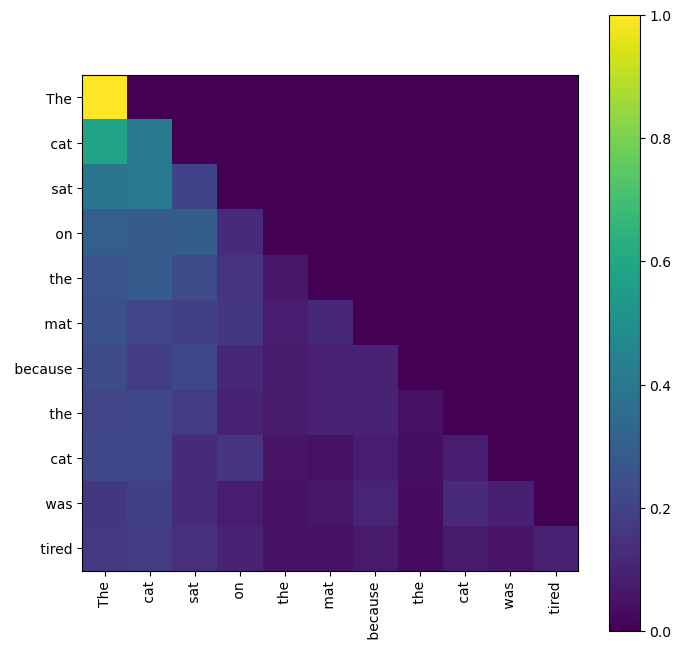

In [10]:
import matplotlib.pyplot as plt
head0=att[0,0]

plt.figure(figsize=(8,8))
plt.imshow(head0)
plt.xticks(range(len(token_strings)),token_strings,rotation=90)
plt.yticks(range(len(token_strings)),token_strings)
plt.colorbar()
plt.show()

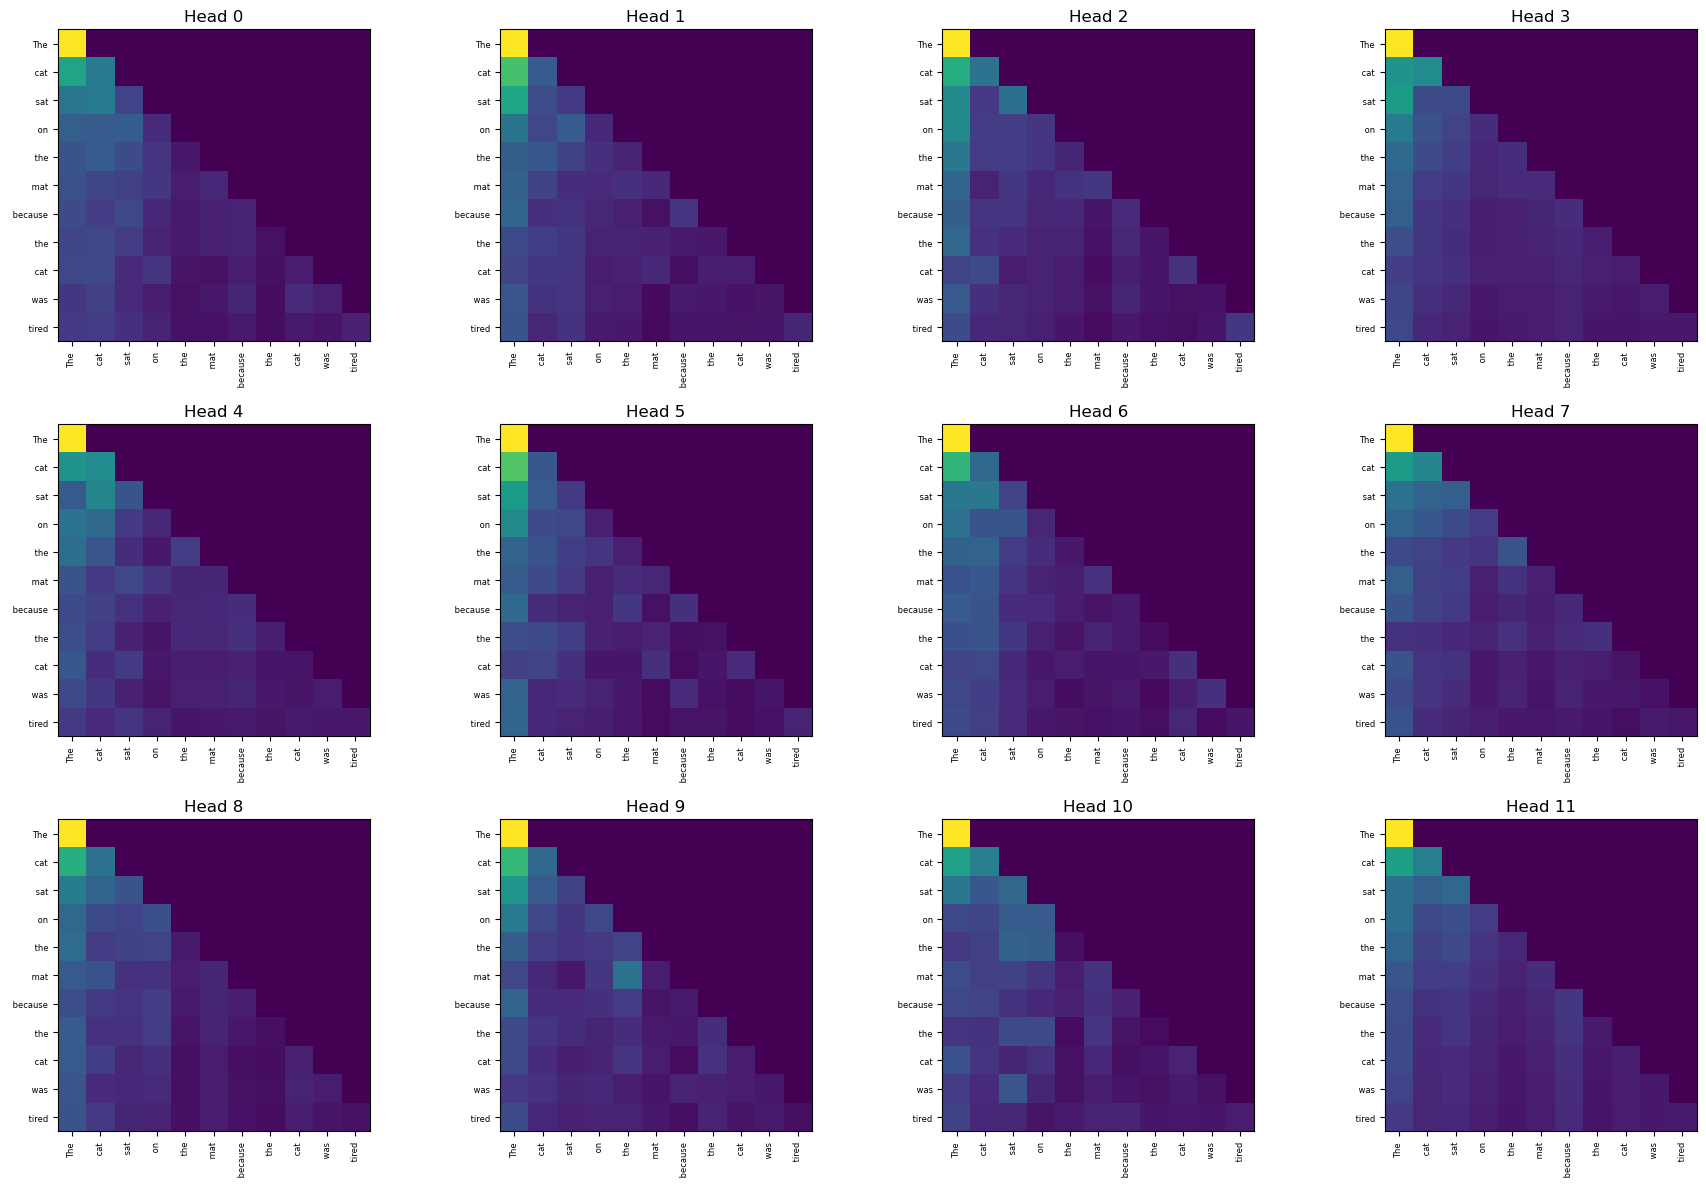

In [12]:
fig,axes=plt.subplots(nrows=3,ncols=4,figsize=(18,12))
for h in range(12):
    row= h//4
    col= h%4
    ax=axes[row,col]
    ax.imshow(att[0,h])
    ax.set_title(f"Head {h}")
    ax.set_xticks(range(len(token_strings)))
    ax.set_xticklabels(token_strings,rotation=90,fontsize=6)
    ax.set_yticks(range(len(token_strings)))
    ax.set_yticklabels(token_strings,fontsize=6)

plt.tight_layout()
plt.show()

In [13]:
att_1=model.transformer.h[1].attn.last_att

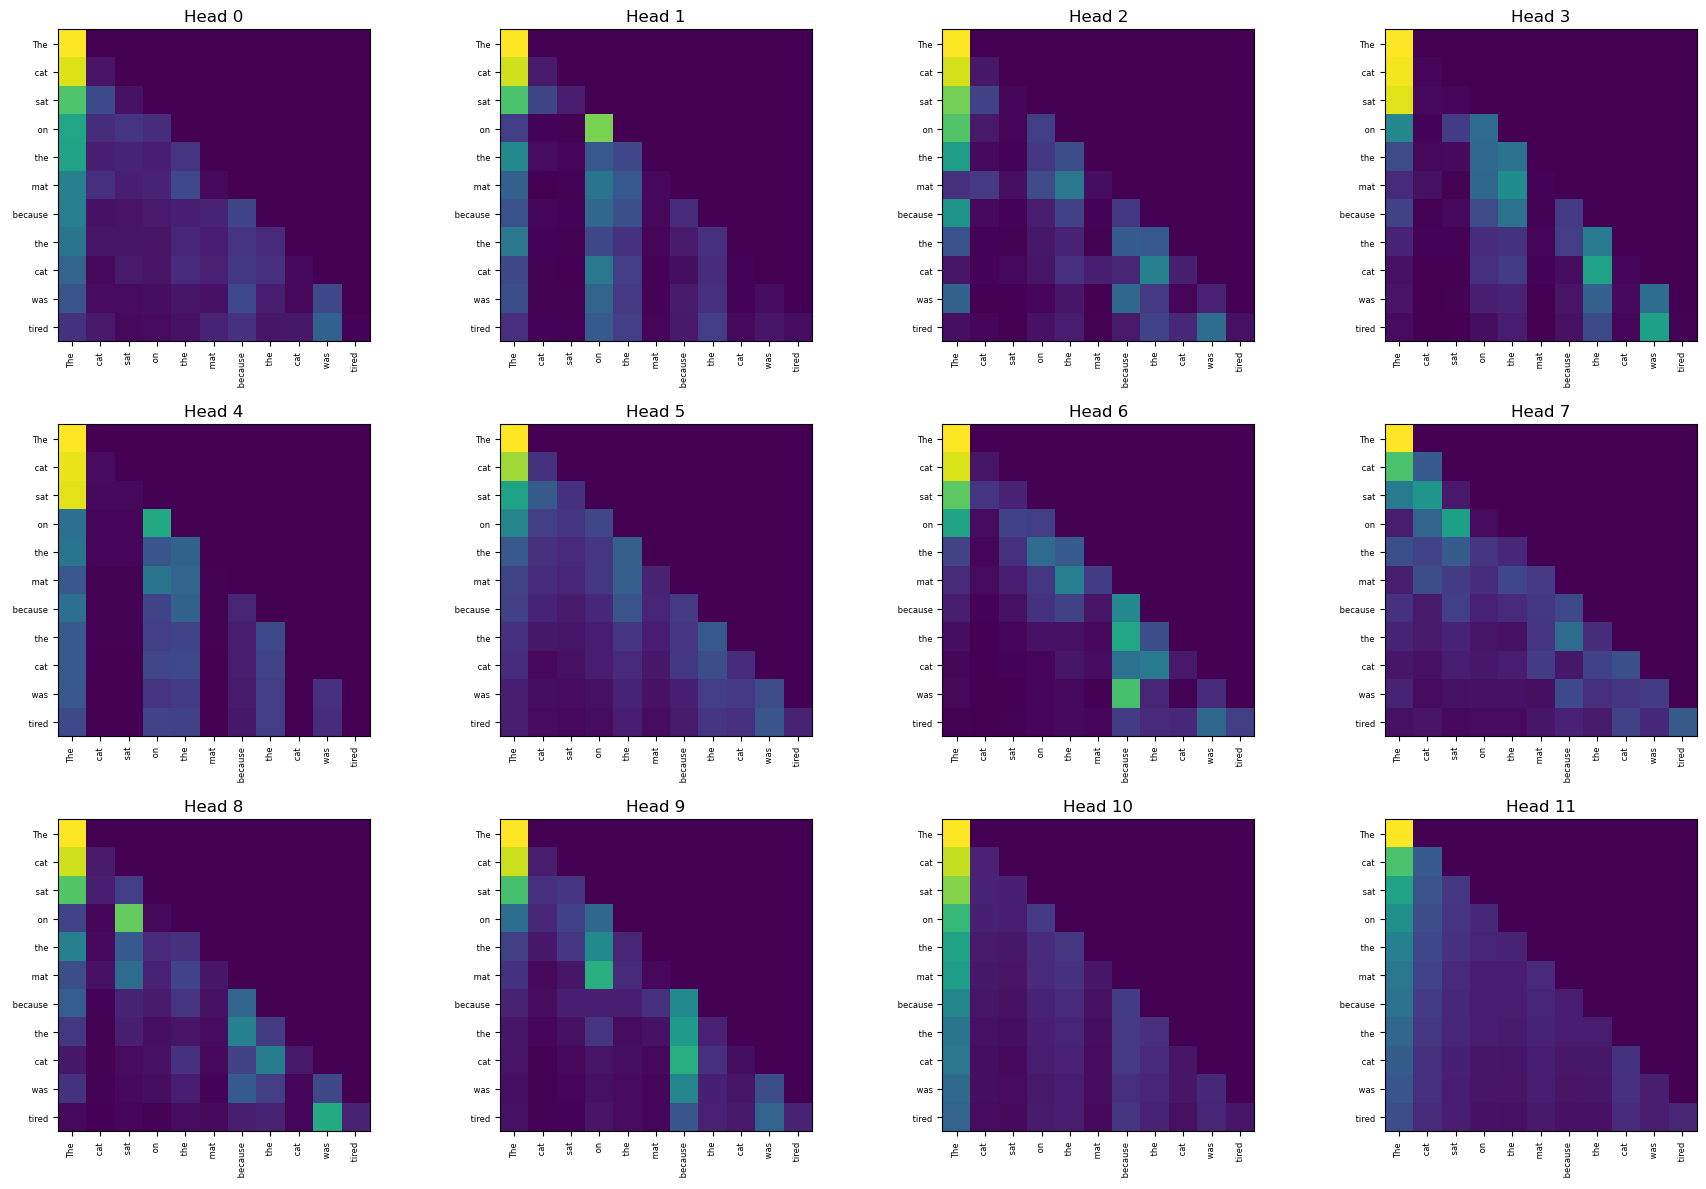

In [14]:
fig,axes=plt.subplots(nrows=3,ncols=4,figsize=(18,12))
for h in range(12):
    row= h//4
    col= h%4
    ax=axes[row,col]
    ax.imshow(att_1[0,h])
    ax.set_title(f"Head {h}")
    ax.set_xticks(range(len(token_strings)))
    ax.set_xticklabels(token_strings,rotation=90,fontsize=6)
    ax.set_yticks(range(len(token_strings)))
    ax.set_yticklabels(token_strings,fontsize=6)

plt.tight_layout()
plt.show()